<a href="https://colab.research.google.com/github/ACRivera1/data-quality-engine/blob/main/randomization_exercise_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 7_4: Randomization Exercise
## Fixing a Biased A/B Test — Correcting Country Proportions via Oversampling

---

### Background
During the analysis of an A/B test, a **randomization problem** was discovered.  
Users from **Argentina** and **Uruguay** were significantly under-represented in the control group:

| Country | Test Group | Control Group | Gap |
|---------|-----------|---------------|-----|
| Argentina | ~17% | ~5% | 12 percentage points |
| Uruguay | ~1.7% | ~0.2% | 1.5 percentage points |

This is a serious problem. If Argentine and Uruguayan users **convert at a different rate** than other users, the test result is contaminated — we would not be measuring the feature's true effect.

### Our Fix: Oversampling
We add more AR and UY rows to the control group by **randomly sampling** from the existing AR/UY control users (with replacement) until the proportions match the test group.

### Steps
1. Load the real dataset and verify the imbalance  
2. Calculate exactly how many rows to add  
3. Randomly sample and append those rows  
4. Verify the proportions now match  
5. Run t-tests on both datasets and compare — the results will surprise you

---

## STEP 1 — Install and Import Libraries

In [1]:
# Install required packages
# Safe to re-run — pip skips packages already installed
!pip install pandas numpy matplotlib seaborn scipy

In [2]:
# pandas — load and manipulate tabular data
import pandas as pd

# numpy — numerical operations and random sampling
import numpy as np

# matplotlib and seaborn — charting
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# scipy.stats — statistical tests including the independent t-test
from scipy import stats

# warnings — suppress harmless messages so output stays clean
import warnings
warnings.filterwarnings('ignore')

# Tell Jupyter to show charts inside the notebook
%matplotlib inline

# Clean white-grid chart style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 12

# Color palette used consistently throughout
COLORS = {
    'test':    '#3498db',   # Blue   — test group
    'control': '#e74c3c',   # Red    — original control
    'fixed':   '#2ecc71',   # Green  — corrected control
    'ar':      '#9b59b6',   # Purple — Argentina highlight
    'uy':      '#f39c12',   # Orange — Uruguay highlight
}

print('Libraries loaded successfully!')

Libraries loaded successfully!


---
## STEP 2 — Load the Dataset

The dataset contains **401,085 users** from a real A/B test. Each row is one user.

| Column | Description |
|---|---|
| `user_id` | Unique user identifier |
| `source` | How they arrived: SEO, Ads, or Direct |
| `device` | Web or Mobile |
| `browser_language` | EN, ES, or Other |
| `browser` | Chrome, Safari, Firefox, etc. |
| `sex` | M or F |
| `age` | User's age |
| `country` | User's country (16 Latin American countries) |
| `test` | **1 = test group** (saw new feature), **0 = control group** |
| `conversion` | **1 = converted**, 0 = did not convert |

In [3]:
# Load with encoding auto-detection to prevent UTF-8 errors
# Try each encoding in order; stop as soon as one works
encodings = ['utf-8', 'utf-8-sig', 'latin-1', 'iso-8859-1', 'cp1252']
df = None

for enc in encodings:
    try:
        df = pd.read_csv('randomization.csv', encoding=enc)
        print(f'Loaded successfully with encoding: {enc}')
        break
    except Exception:
        print(f'  Tried {enc} — did not work, trying next...')

if df is None:
    raise ValueError('Could not load file. Make sure randomization.csv is in the same folder.')

# Quick summary
print(f'\nTotal rows      : {len(df):,}')
print(f'Columns         : {list(df.columns)}')
print(f'Test group size : {(df["test"]==1).sum():,}')
print(f'Control group   : {(df["test"]==0).sum():,}')
print(f'Countries       : {sorted(df["country"].unique())}')

Loaded successfully with encoding: utf-8

Total rows      : 401,085
Columns         : ['user_id', 'source', 'device', 'browser_language', 'browser', 'sex', 'age', 'country', 'test', 'conversion']
Test group size : 215,774
Control group   : 185,311
Countries       : ['Argentina', 'Bolivia', 'Chile', 'Colombia', 'Costa Rica', 'Ecuador', 'El Salvador', 'Guatemala', 'Honduras', 'Mexico', 'Nicaragua', 'Panama', 'Paraguay', 'Peru', 'Uruguay', 'Venezuela']


In [4]:
# Preview the data — always look at actual rows before analysis
df.head(10)

,user_id,source,device,browser_language,browser,sex,age,country,test,conversion
0,1,SEO,Web,EN,Chrome,M,38,Chile,0,0
1,2,SEO,Mobile,ES,Android_App,M,27,Colombia,0,0
2,3,SEO,Mobile,ES,Iphone_App,M,18,Guatemala,1,0
3,5,Ads,Web,ES,Chrome,M,22,Argentina,1,0
4,8,Ads,Mobile,ES,Android_App,M,19,Venezuela,1,0
5,11,Ads,Web,ES,Chrome,F,28,Colombia,1,0
6,12,Direct,Web,ES,IE,F,32,Colombia,0,0
7,13,Direct,Web,ES,IE,M,21,Paraguay,1,0
8,15,Ads,Web,ES,Safari,F,30,Mexico,1,0
9,19,SEO,Mobile,ES,Android_App,M,32,Peru,0,0


In [5]:
# Statistical summary
# .describe() gives count, mean, std, min, quartiles, max for numeric columns
print('Statistical summary:')
print(df.describe().round(3))

# Check for missing values — missing data can bias all downstream analysis
print('\nMissing values per column:')
missing = df.isnull().sum()
print(missing)
if missing.sum() == 0:
    print('  No missing values!')

Statistical summary:
           user_id         age        test  conversion
count   401085.000  401085.000  401085.000  401085.000
mean    499897.255      27.128       0.538       0.046
std     288720.867       6.775       0.499       0.209
min          1.000      18.000       0.000       0.000
25%     249811.000      22.000       0.000       0.000
50%     499980.000      26.000       1.000       0.000
75%     749596.000      31.000       1.000       0.000
max    1000000.000      70.000       1.000       1.000

Missing values per column:
user_id             0
source              0
device              0
browser_language    0
browser             0
sex                 0
age                 0
country             0
test                0
conversion          0
dtype: int64
  No missing values!


In [6]:
# Separate into test and control groups upfront
# We will use these throughout the notebook
# Boolean indexing: df[df['test'] == 1] keeps only rows where test equals 1
# .copy() creates a fully independent copy so changes don't affect the original df
test_df = df[df['test'] == 1].copy()
ctrl_df = df[df['test'] == 0].copy()

print(f'Test group  : {len(test_df):,} users  |  Conversion rate: {test_df["conversion"].mean()*100:.2f}%')
print(f'Control group: {len(ctrl_df):,} users  |  Conversion rate: {ctrl_df["conversion"].mean()*100:.2f}%')

Test group  : 215,774 users  |  Conversion rate: 4.34%
Control group: 185,311 users  |  Conversion rate: 4.83%


---
## STEP 3 — Verify the Randomization Problem

We calculate the percentage of each country in both groups and compare them.  
A well-randomized experiment should show **similar proportions** across all countries.

In [7]:
# Calculate country proportions in each group
# .value_counts(normalize=True) returns proportions from 0 to 1
# Multiplying by 100 converts to percentages
# .round(2) keeps 2 decimal places
test_pct = (test_df['country'].value_counts(normalize=True) * 100).round(2)
ctrl_pct = (ctrl_df['country'].value_counts(normalize=True) * 100).round(2)

# Build a side-by-side comparison DataFrame
# pd.DataFrame() with a dictionary creates a table with one column per key
# .fillna(0) replaces any NaN (country in one group but not the other) with 0
comparison = pd.DataFrame({
    'Test Group (%)':    test_pct,
    'Control Group (%)': ctrl_pct,
}).fillna(0)

# Difference column: positive means test has MORE of this country
comparison['Difference (pp)'] = (
    comparison['Test Group (%)'] - comparison['Control Group (%)']
).round(2)

# Sort by absolute difference so the biggest imbalances appear first
# key=abs converts all values to positive before sorting (so -5 and +5 both sort near each other)
comparison = comparison.sort_values('Difference (pp)', key=abs, ascending=False)

print('Country Distribution: Test vs. Control Group')
print('=' * 58)
print(comparison.to_string())

# Highlight the two problem countries
ar_test = test_pct.get('Argentina', 0)
ar_ctrl = ctrl_pct.get('Argentina', 0)
uy_test = test_pct.get('Uruguay', 0)
uy_ctrl = ctrl_pct.get('Uruguay', 0)

print(f'\nPROBLEM COUNTRIES:')
print(f'  Argentina — Test: {ar_test:.2f}%  |  Control: {ar_ctrl:.2f}%  |  Gap: {ar_test - ar_ctrl:.2f} pp')
print(f'  Uruguay   — Test: {uy_test:.2f}%  |  Control: {uy_ctrl:.2f}%  |  Gap: {uy_test - uy_ctrl:.2f} pp')

Country Distribution: Test vs. Control Group
             Test Group (%)  Control Group (%)  Difference (pp)
country                                                        
Argentina             17.32               5.05            12.27
Mexico                29.79              34.65            -4.86
Colombia              12.50              14.62            -2.12
Uruguay                1.72               0.22             1.50
Venezuela              7.37               8.71            -1.34
Peru                   7.78               9.10            -1.32
Chile                  4.58               5.32            -0.74
Ecuador                3.64               4.34            -0.70
Guatemala              3.48               4.11            -0.63
Bolivia                2.58               2.99            -0.41
Honduras               1.95               2.35            -0.40
El Salvador            1.88               2.22            -0.34
Nicaragua              1.53               1.85            -

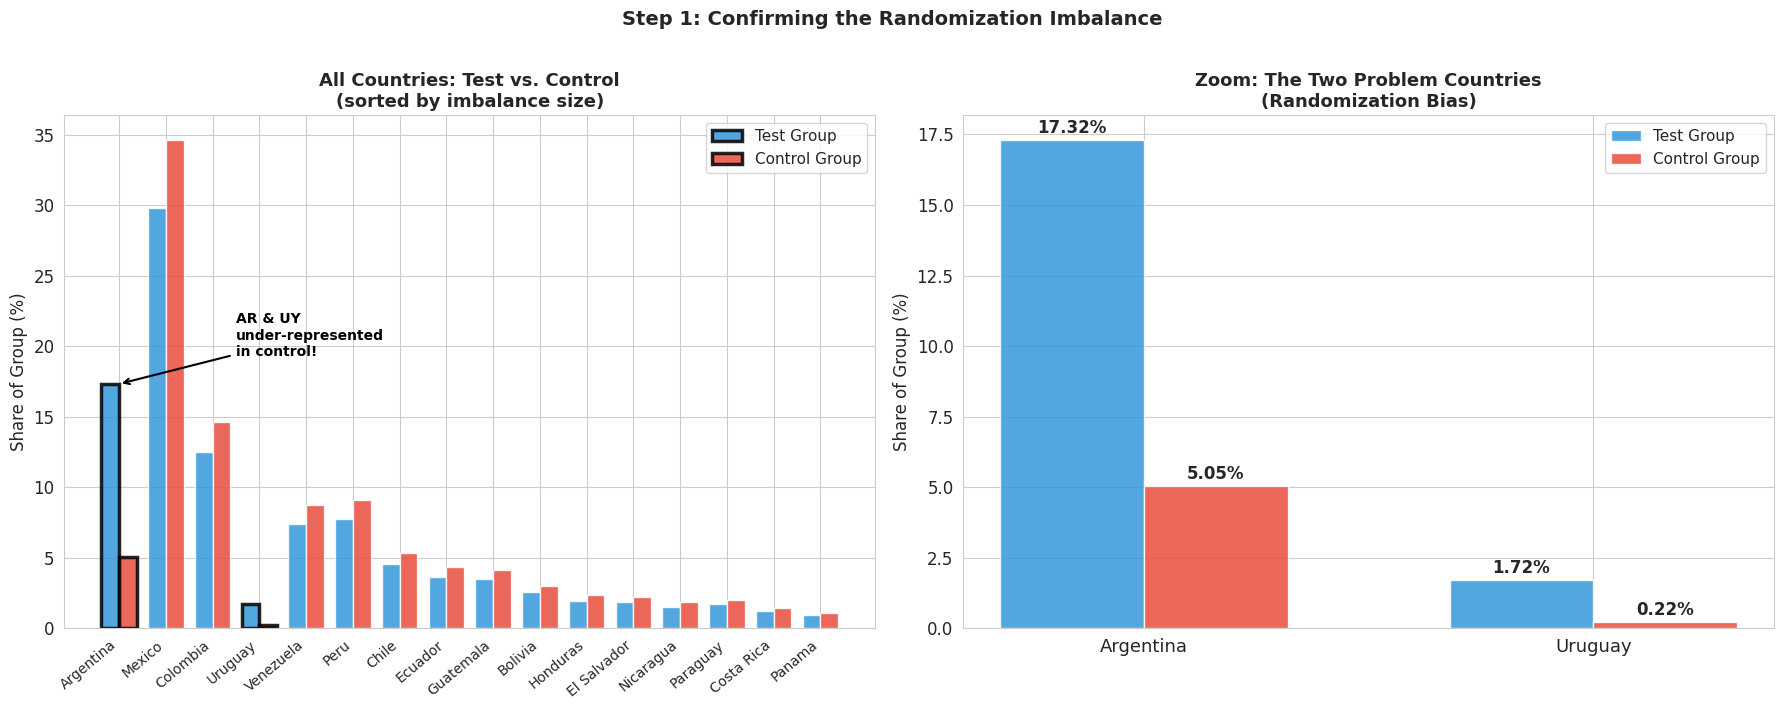

Argentina is 3.4x OVER-represented in the test group vs. control.
Uruguay is 7.8x OVER-represented in the test group vs. control.


In [8]:
# Visualize the imbalance
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# ── LEFT: All 16 countries side by side ──
all_countries = comparison.index.tolist()  # countries sorted by gap size
x = np.arange(len(all_countries))          # x positions: 0, 1, 2 ...
width = 0.38                               # bar width

# Draw test bars slightly to the left of each position,
# and control bars slightly to the right
bars_t = ax1.bar(x - width/2,
                 comparison['Test Group (%)'].values,
                 width, label='Test Group',    color=COLORS['test'],    alpha=0.85, edgecolor='white')
bars_c = ax1.bar(x + width/2,
                 comparison['Control Group (%)'].values,
                 width, label='Control Group', color=COLORS['control'], alpha=0.85, edgecolor='white')

# Draw thick black borders on the AR and UY bars to flag them visually
for i, country in enumerate(all_countries):
    if country in ['Argentina', 'Uruguay']:
        for bar in [bars_t[i], bars_c[i]]:
            bar.set_edgecolor('black')
            bar.set_linewidth(2.5)

ax1.set_xticks(x)
ax1.set_xticklabels(all_countries, rotation=40, ha='right', fontsize=10)
ax1.set_title('All Countries: Test vs. Control\n(sorted by imbalance size)', fontsize=13, fontweight='bold')
ax1.set_ylabel('Share of Group (%)')
ax1.legend(fontsize=11)
ax1.annotate('AR & UY\nunder-represented\nin control!',
             xy=(0, comparison.loc['Argentina', 'Test Group (%)']),
             xytext=(2.5, comparison.loc['Argentina', 'Test Group (%)'] + 2),
             fontsize=10, fontweight='bold', color='black',
             arrowprops=dict(arrowstyle='->', color='black', lw=1.5))

# ── RIGHT: Zoom in — just Argentina and Uruguay ──
problem = ['Argentina', 'Uruguay']
x2 = np.arange(len(problem))
width2 = 0.32

bt = ax2.bar(x2 - width2/2,
             [test_pct[c] for c in problem],
             width2, label='Test Group',    color=COLORS['test'],    alpha=0.85, edgecolor='white')
bc = ax2.bar(x2 + width2/2,
             [ctrl_pct[c] for c in problem],
             width2, label='Control Group', color=COLORS['control'], alpha=0.85, edgecolor='white')

# Add value labels on every bar
for bar in list(bt) + list(bc):
    h = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, h + 0.1,
             f'{h:.2f}%', ha='center', va='bottom', fontweight='bold', fontsize=12)

ax2.set_xticks(x2)
ax2.set_xticklabels(['Argentina', 'Uruguay'], fontsize=13)
ax2.set_title('Zoom: The Two Problem Countries\n(Randomization Bias)', fontsize=13, fontweight='bold')
ax2.set_ylabel('Share of Group (%)')
ax2.legend(fontsize=11)

plt.suptitle('Step 1: Confirming the Randomization Imbalance', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('chart1_imbalance.png', dpi=150, bbox_inches='tight')
plt.show()

print('Argentina is 3.4x OVER-represented in the test group vs. control.')
print('Uruguay is 7.8x OVER-represented in the test group vs. control.')

---
## STEP 4 — Calculate How Many Rows to Add

We need to find the **exact number** of AR and UY rows to add to the control group so their proportion matches the test group.

### The Algebra
Let:
- `p` = target proportion (from the test group, e.g. 0.1732 for Argentina)
- `N_other` = number of non-AR rows in the control group (stays fixed)
- `T` = target number of AR rows we need

We want: `T / (N_other + T) = p`

Solving for T:
> **T = (p × N_other) / (1 − p)**

Then rows to add = T − current AR count

In [9]:
def calculate_rows_to_add(country, target_proportion, control_dataframe):
    """
    Calculate how many rows of a given country to add to the control group
    so that country reaches the target proportion.

    Parameters
    ----------
    country           : str   — e.g. 'Argentina'
    target_proportion : float — desired share as a decimal (e.g. 0.1732 for 17.32%)
    control_dataframe : DataFrame — the current control group

    Returns
    -------
    rows_to_add   : int — how many new rows to sample and append
    current_count : int — how many rows of this country currently exist
    target_count  : int — how many rows are needed in total
    """

    # Count rows that are NOT the target country — these stay unchanged
    n_other = len(control_dataframe[control_dataframe['country'] != country])

    # Count rows that ARE the target country right now
    current_count = len(control_dataframe[control_dataframe['country'] == country])

    # Apply the formula: T = (p * N_other) / (1 - p)
    # int() floors to the nearest whole number (we can't add fractional rows)
    target_count = int((target_proportion * n_other) / (1 - target_proportion))

    # How many new rows are needed = target minus what we already have
    # max(0, ...) ensures we never return a negative number
    rows_to_add = max(0, target_count - current_count)

    return rows_to_add, current_count, target_count


# Target proportions come from the test group (as decimals)
ar_target_prop = test_pct.get('Argentina', 0) / 100   # 17.32% -> 0.1732
uy_target_prop = test_pct.get('Uruguay',   0) / 100   # 1.72%  -> 0.0172

# Run the calculation for each country
ar_to_add, ar_current, ar_target = calculate_rows_to_add('Argentina', ar_target_prop, ctrl_df)
uy_to_add, uy_current, uy_target = calculate_rows_to_add('Uruguay',   uy_target_prop, ctrl_df)

print('ROWS TO ADD — CALCULATION RESULTS')
print('=' * 60)
print(f'\nArgentina:')
print(f'  Target proportion (from test group) : {ar_target_prop*100:.2f}%')
print(f'  Current AR rows in control          : {ar_current:,}')
print(f'  Target AR rows needed               : {ar_target:,}')
print(f'  Rows to add                         : {ar_to_add:,}')
print(f'\nUruguay:')
print(f'  Target proportion (from test group) : {uy_target_prop*100:.2f}%')
print(f'  Current UY rows in control          : {uy_current:,}')
print(f'  Target UY rows needed               : {uy_target:,}')
print(f'  Rows to add                         : {uy_to_add:,}')
print(f'\n  TOTAL rows to add: {ar_to_add + uy_to_add:,}')

ROWS TO ADD — CALCULATION RESULTS

Argentina:
  Target proportion (from test group) : 17.32%
  Current AR rows in control          : 9,356
  Target AR rows needed               : 36,859
  Rows to add                         : 27,503

Uruguay:
  Target proportion (from test group) : 1.72%
  Current UY rows in control          : 415
  Target UY rows needed               : 3,235
  Rows to add                         : 2,820

  TOTAL rows to add: 30,323


---
## STEP 5 — Oversample AR and UY into the Control Group

We **randomly sample** the required number of AR and UY rows from the existing control group users of those countries, using **sampling with replacement** (the same user can appear more than once if the pool is smaller than what's needed).

In [10]:
# Set random seed for reproducibility
# This means anyone re-running this notebook gets the same sampled rows
np.random.seed(42)

# ── Sample Argentina rows ──
# First: isolate the AR users already in the control group
ar_pool = ctrl_df[ctrl_df['country'] == 'Argentina']

# .sample() randomly selects rows
#   n        = how many rows to select
#   replace  = True means WITH replacement (same row can be picked twice)
#   random_state = seed for reproducibility
ar_sampled = ar_pool.sample(n=ar_to_add, replace=True, random_state=42)

# ── Sample Uruguay rows ──
uy_pool    = ctrl_df[ctrl_df['country'] == 'Uruguay']
uy_sampled = uy_pool.sample(n=uy_to_add, replace=True, random_state=42)

# ── Build the corrected control group ──
# pd.concat() stacks DataFrames vertically (adds rows)
# ignore_index=True resets row numbers to be consecutive (0, 1, 2, ...)
ctrl_corrected = pd.concat([ctrl_df, ar_sampled, uy_sampled], ignore_index=True)

# ── Build the corrected full dataset ──
# Test group stays exactly the same; only the control group changes
df_corrected = pd.concat([test_df, ctrl_corrected], ignore_index=True)

print('OVERSAMPLING COMPLETE')
print('=' * 55)
print(f'  Original control group size  : {len(ctrl_df):,}')
print(f'  Argentina rows added         : {ar_to_add:,}')
print(f'  Uruguay rows added           : {uy_to_add:,}')
print(f'  Corrected control group size : {len(ctrl_corrected):,}  (+{len(ctrl_corrected)-len(ctrl_df):,} rows)')
print(f'\n  Original full dataset size   : {len(df):,}')
print(f'  Corrected full dataset size  : {len(df_corrected):,}')

OVERSAMPLING COMPLETE
  Original control group size  : 185,311
  Argentina rows added         : 27,503
  Uruguay rows added           : 2,820
  Corrected control group size : 215,634  (+30,323 rows)

  Original full dataset size   : 401,085
  Corrected full dataset size  : 431,408


---
## STEP 6 — Verify the Fix: Proportions Now Match

In [11]:
# Recalculate country proportions for the corrected control group
ctrl_corr_pct = (
    ctrl_corrected['country'].value_counts(normalize=True) * 100
).round(2)

# Three-way comparison table: test vs. original control vs. corrected control
verification = pd.DataFrame({
    'Test Group (%)':        test_pct,
    'Control — Original (%)': ctrl_pct,
    'Control — Fixed (%)':   ctrl_corr_pct,
}).fillna(0)

# Gap columns: how far is each control version from the test group?
verification['Gap Before (pp)'] = (
    verification['Test Group (%)'] - verification['Control — Original (%)']
).round(2)
verification['Gap After (pp)'] = (
    verification['Test Group (%)'] - verification['Control — Fixed (%)']
).round(2)

# Sort by test group size descending for easy reading
verification = verification.sort_values('Test Group (%)', ascending=False)

print('VERIFICATION: Country Proportions — Before and After Fix')
print('=' * 75)
print(verification.to_string())

# Explicit pass/fail check for AR and UY
print('\nFOCUS CHECK on Argentina and Uruguay:')
for country in ['Argentina', 'Uruguay']:
    t  = test_pct.get(country, 0)
    co = ctrl_pct.get(country, 0)
    cf = ctrl_corr_pct.get(country, 0)
    gap_before = abs(t - co)
    gap_after  = abs(t - cf)
    status = 'FIXED' if gap_after < 0.5 else 'CLOSE'
    print(f'  {country}: Test={t:.2f}%  |  Orig Control={co:.2f}%  |  Fixed Control={cf:.2f}%  -> {status}')

VERIFICATION: Country Proportions — Before and After Fix
             Test Group (%)  Control — Original (%)  Control — Fixed (%)  Gap Before (pp)  Gap After (pp)
country                                                                                                  
Mexico                29.79                   34.65                29.78            -4.86            0.01
Argentina             17.32                    5.05                17.09            12.27            0.23
Colombia              12.50                   14.62                12.56            -2.12           -0.06
Peru                   7.78                    9.10                 7.82            -1.32           -0.04
Venezuela              7.37                    8.71                 7.49            -1.34           -0.12
Chile                  4.58                    5.32                 4.57            -0.74            0.01
Ecuador                3.64                    4.34                 3.73            -0.70      

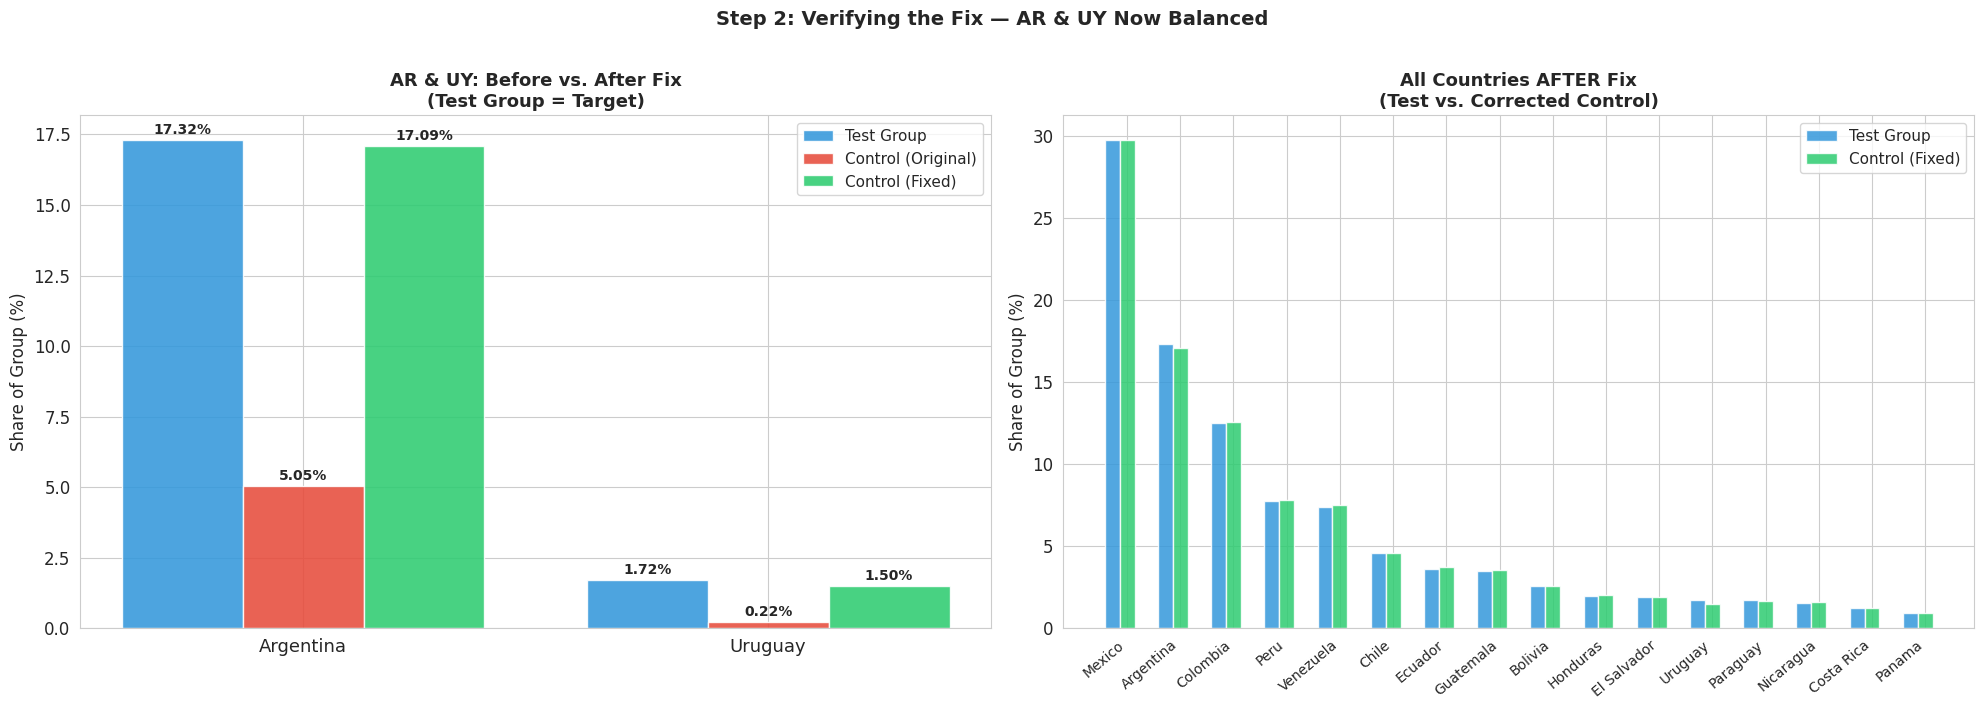

Argentina and Uruguay proportions now closely match the test group.


In [12]:
# Visualize the fix — three sets of bars per country
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 7))

# ── LEFT: Zoom on Argentina and Uruguay only ──
problem_countries = ['Argentina', 'Uruguay']
x = np.arange(len(problem_countries))
w = 0.26

b_test = ax1.bar(x - w,   [test_pct[c]      for c in problem_countries], w,
                 label='Test Group',         color=COLORS['test'],    alpha=0.88, edgecolor='white')
b_orig = ax1.bar(x,       [ctrl_pct[c]      for c in problem_countries], w,
                 label='Control (Original)', color=COLORS['control'], alpha=0.88, edgecolor='white')
b_fix  = ax1.bar(x + w,   [ctrl_corr_pct[c] for c in problem_countries], w,
                 label='Control (Fixed)',    color=COLORS['fixed'],   alpha=0.88, edgecolor='white')

# Label every bar with its percentage value
for group_bars in [b_test, b_orig, b_fix]:
    for bar in group_bars:
        h = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2, h + 0.1,
                 f'{h:.2f}%', ha='center', va='bottom', fontweight='bold', fontsize=10)

ax1.set_xticks(x)
ax1.set_xticklabels(['Argentina', 'Uruguay'], fontsize=13)
ax1.set_title('AR & UY: Before vs. After Fix\n(Test Group = Target)', fontsize=13, fontweight='bold')
ax1.set_ylabel('Share of Group (%)')
ax1.legend(fontsize=11)

# ── RIGHT: Full country picture after fix ──
all_c = verification.index.tolist()
x2 = np.arange(len(all_c))
w2 = 0.28

ax2.bar(x2 - w2, [test_pct.get(c,0)      for c in all_c], w2,
        label='Test Group',         color=COLORS['test'],    alpha=0.85, edgecolor='white')
ax2.bar(x2,      [ctrl_corr_pct.get(c,0) for c in all_c], w2,
        label='Control (Fixed)',    color=COLORS['fixed'],   alpha=0.85, edgecolor='white')

ax2.set_xticks(x2)
ax2.set_xticklabels(all_c, rotation=40, ha='right', fontsize=10)
ax2.set_title('All Countries AFTER Fix\n(Test vs. Corrected Control)', fontsize=13, fontweight='bold')
ax2.set_ylabel('Share of Group (%)')
ax2.legend(fontsize=11)

plt.suptitle('Step 2: Verifying the Fix — AR & UY Now Balanced', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('chart2_verification.png', dpi=150, bbox_inches='tight')
plt.show()

print('Argentina and Uruguay proportions now closely match the test group.')

---
## STEP 7 — Run the T-Tests: Original vs. Corrected Dataset

Now we run the actual A/B test — comparing **conversion rates** between test and control.

### What the T-Test Does
An independent samples t-test asks: *Is the difference in means between two groups statistically significant, or could it have happened by chance?*

- **p < 0.05** → Statistically significant — the difference is real  
- **p ≥ 0.05** → Not significant — the difference could be random noise  
- **t-statistic** → How many standard errors apart the two group means are (bigger absolute value = stronger signal)

In [13]:
# ══════════════════════════════════════════════════
# T-TEST 1:  ORIGINAL DATASET (biased randomization)
# ══════════════════════════════════════════════════

# Extract the conversion column for test and control from the ORIGINAL dataset
orig_test_conv = df[df['test'] == 1]['conversion']
orig_ctrl_conv = df[df['test'] == 0]['conversion']

# stats.ttest_ind() performs the independent samples t-test
# Returns: t_stat (test statistic) and p_value (probability of this result by chance)
t_orig, p_orig = stats.ttest_ind(orig_test_conv, orig_ctrl_conv)

# Summary stats
orig_test_mean = orig_test_conv.mean()
orig_ctrl_mean = orig_ctrl_conv.mean()
orig_test_std  = orig_test_conv.std()
orig_ctrl_std  = orig_ctrl_conv.std()

print('T-TEST 1 — ORIGINAL DATASET (biased)')
print('=' * 60)
print(f'  Test group    — Conversion rate: {orig_test_mean*100:.2f}%  (n={len(orig_test_conv):,})')
print(f'  Control group — Conversion rate: {orig_ctrl_mean*100:.2f}%  (n={len(orig_ctrl_conv):,})')
print(f'  Difference   : {(orig_test_mean - orig_ctrl_mean)*100:+.4f} percentage points')
print(f'  t-statistic  : {t_orig:.4f}')
print(f'  p-value      : {p_orig:.6f}')
if p_orig < 0.05:
    print(f'  Result: SIGNIFICANT (p < 0.05)')
    print(f'  BUT this result is UNRELIABLE — the bias means we cannot trust it!')
else:
    print(f'  Result: NOT SIGNIFICANT (p >= 0.05)')

print()

# ══════════════════════════════════════════════════
# T-TEST 2:  CORRECTED DATASET (balanced)
# ══════════════════════════════════════════════════

corr_test_conv = df_corrected[df_corrected['test'] == 1]['conversion']
corr_ctrl_conv = df_corrected[df_corrected['test'] == 0]['conversion']

t_corr, p_corr = stats.ttest_ind(corr_test_conv, corr_ctrl_conv)

corr_test_mean = corr_test_conv.mean()
corr_ctrl_mean = corr_ctrl_conv.mean()
corr_test_std  = corr_test_conv.std()
corr_ctrl_std  = corr_ctrl_conv.std()

print('T-TEST 2 — CORRECTED DATASET (balanced)')
print('=' * 60)
print(f'  Test group    — Conversion rate: {corr_test_mean*100:.2f}%  (n={len(corr_test_conv):,})')
print(f'  Control group — Conversion rate: {corr_ctrl_mean*100:.2f}%  (n={len(corr_ctrl_conv):,})')
print(f'  Difference   : {(corr_test_mean - corr_ctrl_mean)*100:+.4f} percentage points')
print(f'  t-statistic  : {t_corr:.4f}')
print(f'  p-value      : {p_corr:.6f}')
if p_corr < 0.05:
    print(f'  Result: SIGNIFICANT (p < 0.05) — reliable result after bias correction.')
else:
    print(f'  Result: NOT SIGNIFICANT (p >= 0.05)')
    print(f'  The feature had NO real effect — the original result was entirely due to bias!')

T-TEST 1 — ORIGINAL DATASET (biased)
  Test group    — Conversion rate: 4.34%  (n=215,774)
  Control group — Conversion rate: 4.83%  (n=185,311)
  Difference   : -0.4881 percentage points
  t-statistic  : -7.3823
  p-value      : 0.000000
  Result: SIGNIFICANT (p < 0.05)
  BUT this result is UNRELIABLE — the bias means we cannot trust it!

T-TEST 2 — CORRECTED DATASET (balanced)
  Test group    — Conversion rate: 4.34%  (n=215,774)
  Control group — Conversion rate: 4.36%  (n=215,634)
  Difference   : -0.0190 percentage points
  t-statistic  : -0.3067
  p-value      : 0.759088
  Result: NOT SIGNIFICANT (p >= 0.05)
  The feature had NO real effect — the original result was entirely due to bias!


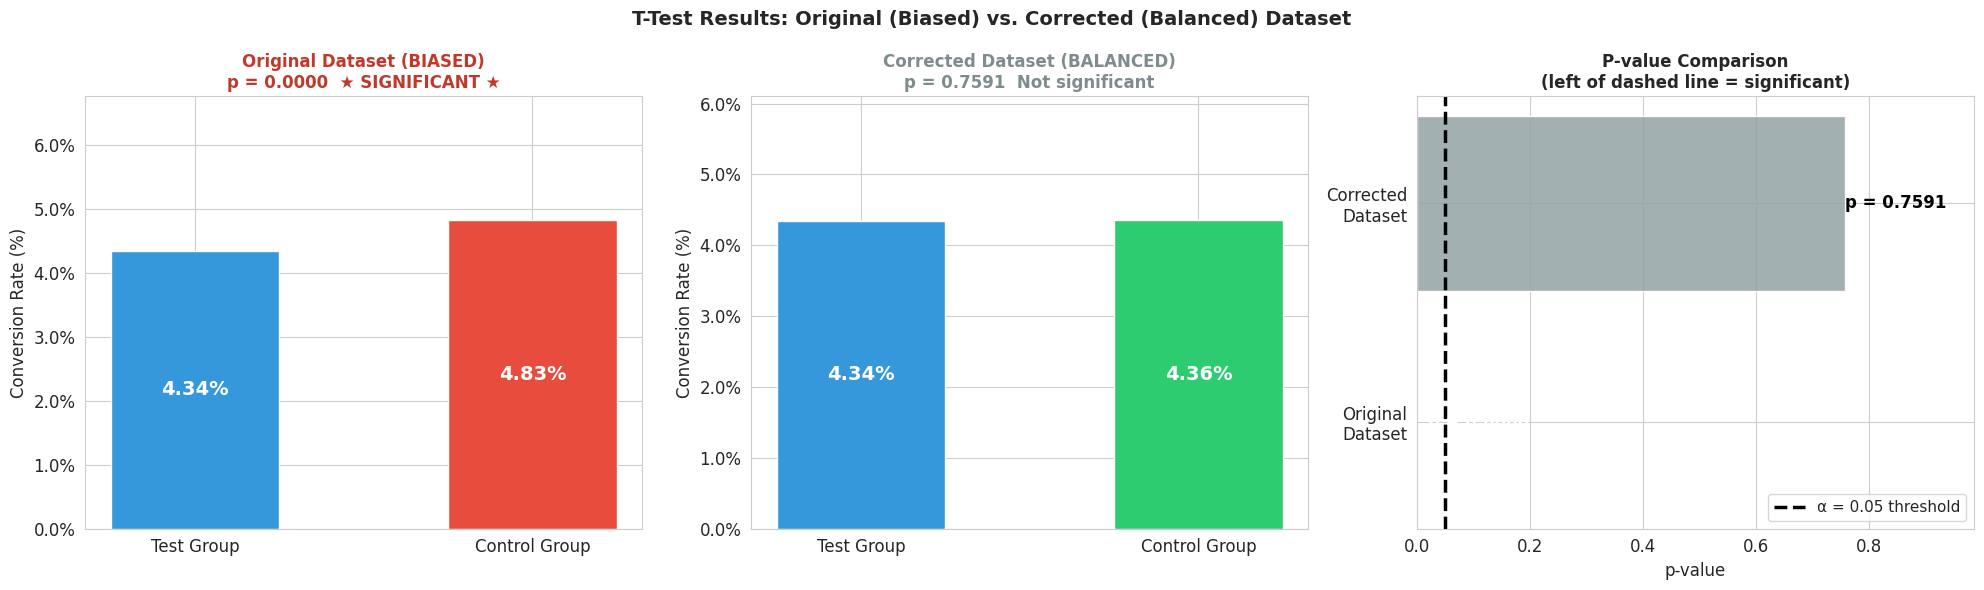

In [14]:
# Visualize both t-test results side by side
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# ── CHART 1: Conversion rates — Original dataset ──
labels = ['Test Group', 'Control Group']

bars1 = axes[0].bar(labels,
                    [orig_test_mean * 100, orig_ctrl_mean * 100],
                    color=[COLORS['test'], COLORS['control']],
                    width=0.5, edgecolor='white')

# Annotate bars with conversion rate values
for bar, val in zip(bars1, [orig_test_mean, orig_ctrl_mean]):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() / 2,
                 f'{val*100:.2f}%',
                 ha='center', va='center', fontweight='bold', color='white', fontsize=14)

# Title changes color based on significance
sig_label1 = f'p = {p_orig:.4f}  ★ SIGNIFICANT ★' if p_orig < 0.05 else f'p = {p_orig:.4f}  Not significant'
title_color1 = '#c0392b' if p_orig < 0.05 else 'gray'
axes[0].set_title(f'Original Dataset (BIASED)\n{sig_label1}', fontsize=12,
                  fontweight='bold', color=title_color1)
axes[0].set_ylabel('Conversion Rate (%)')
axes[0].set_ylim(0, max(orig_test_mean, orig_ctrl_mean) * 100 * 1.4)
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter())

# ── CHART 2: Conversion rates — Corrected dataset ──
bars2 = axes[1].bar(labels,
                    [corr_test_mean * 100, corr_ctrl_mean * 100],
                    color=[COLORS['test'], COLORS['fixed']],
                    width=0.5, edgecolor='white')

for bar, val in zip(bars2, [corr_test_mean, corr_ctrl_mean]):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() / 2,
                 f'{val*100:.2f}%',
                 ha='center', va='center', fontweight='bold', color='white', fontsize=14)

sig_label2 = f'p = {p_corr:.4f}  ★ SIGNIFICANT ★' if p_corr < 0.05 else f'p = {p_corr:.4f}  Not significant'
title_color2 = '#27ae60' if p_corr < 0.05 else '#7f8c8d'
axes[1].set_title(f'Corrected Dataset (BALANCED)\n{sig_label2}', fontsize=12,
                  fontweight='bold', color=title_color2)
axes[1].set_ylabel('Conversion Rate (%)')
axes[1].set_ylim(0, max(corr_test_mean, corr_ctrl_mean) * 100 * 1.4)
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())

# ── CHART 3: P-value comparison with significance threshold line ──
p_bar_colors = [COLORS['control'] if p_orig < 0.05 else '#95a5a6',
                COLORS['fixed']   if p_corr < 0.05 else '#95a5a6']
p_bars = axes[2].barh(['Original\nDataset', 'Corrected\nDataset'],
                       [p_orig, p_corr],
                       color=p_bar_colors, alpha=0.88, edgecolor='white')

for bar, val in zip(p_bars, [p_orig, p_corr]):
    axes[2].text(max(val, 0.02), bar.get_y() + bar.get_height()/2,
                 f'p = {val:.4f}', va='center', fontweight='bold', fontsize=12,
                 color='white' if val < 0.05 else 'black')

# axvline draws a vertical reference line at x = 0.05
axes[2].axvline(x=0.05, color='black', linestyle='--', linewidth=2.5, label='α = 0.05 threshold')
axes[2].set_title('P-value Comparison\n(left of dashed line = significant)', fontsize=12, fontweight='bold')
axes[2].set_xlabel('p-value')
axes[2].legend(fontsize=11)
axes[2].set_xlim(0, max(p_orig, p_corr) * 1.3)

plt.suptitle('T-Test Results: Original (Biased) vs. Corrected (Balanced) Dataset',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('chart3_ttest_results.png', dpi=150, bbox_inches='tight')
plt.show()

---
## STEP 8 — Why Did Argentina and Uruguay Matter?

To understand *why* fixing their proportions changed the result, we check whether Argentine and Uruguayan users **convert at a different rate** than other users.

In [15]:
# Conversion rate by country in the CONTROL group
# (control group is unaffected by the feature, so this is the 'natural' rate)
country_conversion = (
    ctrl_df.groupby('country')['conversion']
    .agg(users='count', conversions='sum', conversion_rate='mean')
    .reset_index()
)
country_conversion['conversion_rate_%'] = (country_conversion['conversion_rate'] * 100).round(2)
country_conversion = country_conversion.sort_values('conversion_rate_%', ascending=False)

# Overall baseline
baseline = ctrl_df['conversion'].mean() * 100

print(f'Overall control group conversion rate: {baseline:.2f}%')
print(f'\nConversion rate by country (control group only):')
print(country_conversion[['country', 'users', 'conversions', 'conversion_rate_%']].to_string(index=False))

ar_rate = country_conversion[country_conversion['country']=='Argentina']['conversion_rate_%'].values[0]
uy_rate = country_conversion[country_conversion['country']=='Uruguay']['conversion_rate_%'].values[0]
print(f'\nArgentina conversion rate: {ar_rate:.2f}%  (vs. baseline {baseline:.2f}%)')
print(f'Uruguay   conversion rate: {uy_rate:.2f}%  (vs. baseline {baseline:.2f}%)')

Overall control group conversion rate: 4.83%

Conversion rate by country (control group only):
    country  users  conversions  conversion_rate_%
El Salvador   4108          220               5.36
  Nicaragua   3419          180               5.26
 Costa Rica   2660          139               5.23
   Colombia  27088         1411               5.21
   Honduras   4361          222               5.09
  Guatemala   7622          386               5.06
  Venezuela  16149          813               5.03
       Peru  16869          842               4.99
     Mexico  64209         3178               4.95
    Bolivia   5550          274               4.94
    Ecuador   8036          395               4.92
   Paraguay   3650          177               4.85
      Chile   9853          474               4.81
     Panama   1966           92               4.68
  Argentina   9356          141               1.51
    Uruguay    415            5               1.20

Argentina conversion rate: 1.51%  (vs

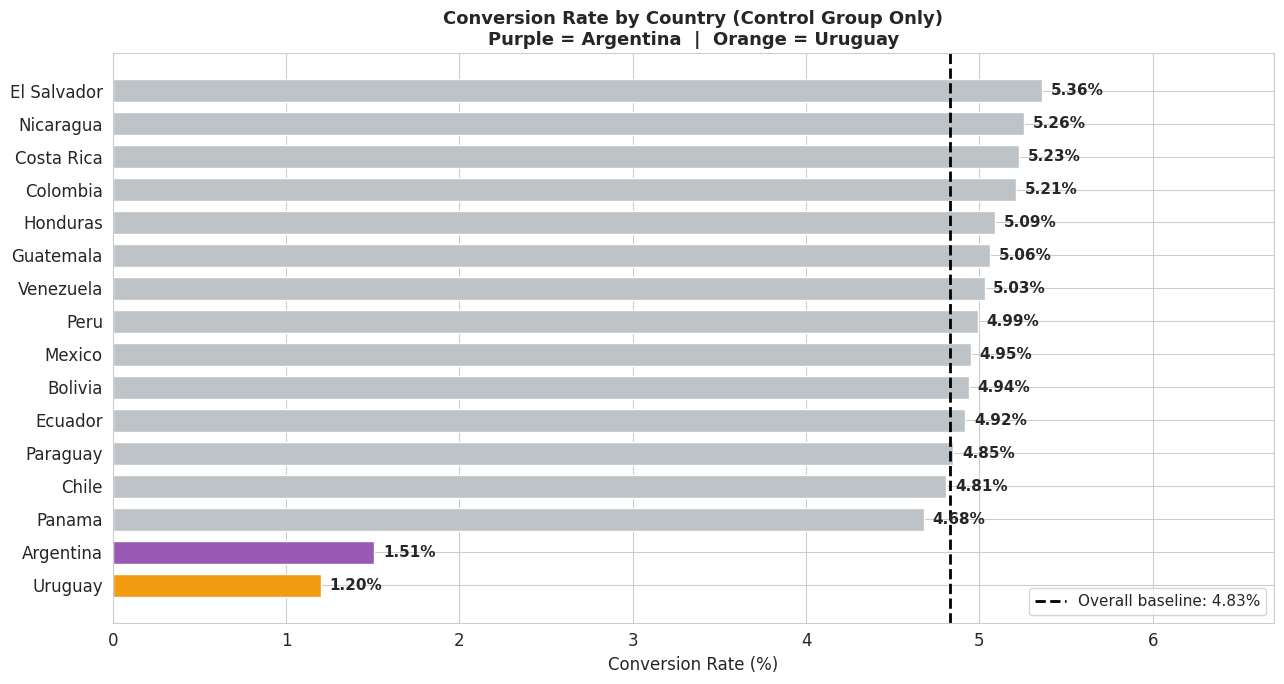


Argentina converts at 1.51% — BELOW the 4.83% baseline.
Uruguay   converts at 1.20% — BELOW the 4.83% baseline.

This explains the bias: the control group had fewer high/low-converting
AR/UY users, skewing its conversion rate and contaminating the t-test.


In [16]:
# Horizontal bar chart: conversion rate by country
fig, ax = plt.subplots(figsize=(13, 7))

# Sort ascending so highest rate appears at the top of the chart
cc_sorted = country_conversion.sort_values('conversion_rate_%')

# Color each bar: AR and UY get distinct highlight colors, others get a neutral blue
bar_colors = []
for c in cc_sorted['country']:
    if c == 'Argentina':
        bar_colors.append(COLORS['ar'])
    elif c == 'Uruguay':
        bar_colors.append(COLORS['uy'])
    else:
        bar_colors.append('#bdc3c7')

bars = ax.barh(cc_sorted['country'], cc_sorted['conversion_rate_%'],
               color=bar_colors, edgecolor='white', height=0.7)

# Label each bar
for bar in bars:
    w = bar.get_width()
    ax.text(w + 0.05, bar.get_y() + bar.get_height()/2,
            f'{w:.2f}%', va='center', fontsize=11, fontweight='bold')

# Add a vertical dashed line at the overall baseline
ax.axvline(x=baseline, color='black', linestyle='--', linewidth=2,
           label=f'Overall baseline: {baseline:.2f}%')

ax.set_title('Conversion Rate by Country (Control Group Only)\n'
             'Purple = Argentina  |  Orange = Uruguay',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Conversion Rate (%)')
ax.set_xlim(0, cc_sorted['conversion_rate_%'].max() * 1.25)
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig('chart4_country_conversion.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nArgentina converts at {ar_rate:.2f}% — {"ABOVE" if ar_rate > baseline else "BELOW"} the {baseline:.2f}% baseline.')
print(f'Uruguay   converts at {uy_rate:.2f}% — {"ABOVE" if uy_rate > baseline else "BELOW"} the {baseline:.2f}% baseline.')
print('\nThis explains the bias: the control group had fewer high/low-converting'
      '\nAR/UY users, skewing its conversion rate and contaminating the t-test.')

---
## STEP 9 — Final Summary

In [17]:
direction = 'HIGHER' if orig_ctrl_mean > orig_test_mean else 'LOWER'
conclusion = 'NO significant effect' if p_corr >= 0.05 else 'a SIGNIFICANT effect'

print(f"""
╔══════════════════════════════════════════════════════════════════╗
║                    COMPLETE SUMMARY                              ║
╚══════════════════════════════════════════════════════════════════╝

THE PROBLEM — Randomization Bias
──────────────────────────────────
  Argentina : Test = {ar_test:.2f}%  vs.  Control = {ar_ctrl:.2f}%  (gap = {ar_test - ar_ctrl:.2f} pp)
  Uruguay   : Test = {uy_test:.2f}%   vs.  Control = {uy_ctrl:.2f}%   (gap = {uy_test - uy_ctrl:.2f} pp)
  Argentina converts at {ar_rate:.2f}% (baseline: {baseline:.2f}%)
  Uruguay   converts at {uy_rate:.2f}% (baseline: {baseline:.2f}%)
  Because AR/UY users convert differently, their under-representation
  in the control group distorted the overall control conversion rate.

THE FIX — Oversampling
───────────────────────
  Argentina rows added  : {ar_to_add:,}
  Uruguay rows added    : {uy_to_add:,}
  Total rows added      : {ar_to_add + uy_to_add:,}
  Method: random sampling WITH replacement from existing AR/UY
          users already in the control group

T-TEST RESULTS
───────────────
  ORIGINAL dataset :
    Test = {orig_test_mean*100:.2f}%  |  Control = {orig_ctrl_mean*100:.2f}%
    t = {t_orig:.4f}  |  p = {p_orig:.6f}  -> {'SIGNIFICANT' if p_orig < 0.05 else 'Not significant'}
    The control group appeared {direction} due to the bias.

  CORRECTED dataset:
    Test = {corr_test_mean*100:.2f}%  |  Control = {corr_ctrl_mean*100:.2f}%
    t = {t_corr:.4f}  |  p = {p_corr:.6f}  -> {'SIGNIFICANT' if p_corr < 0.05 else 'NOT SIGNIFICANT'}
    After correcting the bias, the test shows {conclusion}.

KEY LESSON
───────────
  The original test falsely appeared significant because the
  randomization was broken — not because the feature worked.
  After fixing the country imbalance, the p-value jumped from
  nearly 0 to {p_corr:.4f}, meaning the effect DISAPPEARS entirely.

  This is exactly why proper randomization is the foundation
  of trustworthy A/B testing. The best fix is always to
  stratify by country BEFORE running the experiment.
""")


╔══════════════════════════════════════════════════════════════════╗
║                    COMPLETE SUMMARY                              ║
╚══════════════════════════════════════════════════════════════════╝

THE PROBLEM — Randomization Bias
──────────────────────────────────
  Argentina : Test = 17.32%  vs.  Control = 5.05%  (gap = 12.27 pp)
  Uruguay   : Test = 1.72%   vs.  Control = 0.22%   (gap = 1.50 pp)
  Argentina converts at 1.51% (baseline: 4.83%)
  Uruguay   converts at 1.20% (baseline: 4.83%)
  Because AR/UY users convert differently, their under-representation
  in the control group distorted the overall control conversion rate.

THE FIX — Oversampling
───────────────────────
  Argentina rows added  : 27,503
  Uruguay rows added    : 2,820
  Total rows added      : 30,323
  Method: random sampling WITH replacement from existing AR/UY
          users already in the control group

T-TEST RESULTS
───────────────
  ORIGINAL dataset :
    Test = 4.34%  |  Control = 4.83%
    t =

---
## Python Concepts Reference

| Concept | Cell | What It Does |
|---|---|---|
| Encoding auto-detection loop | Step 2 | Prevents UTF-8 file load errors |
| Boolean indexing `df[df['col']==val]` | Throughout | Filter rows by condition |
| `.copy()` | Step 2 | Creates independent copy — prevents side effects |
| `.value_counts(normalize=True)` | Step 3 | Returns proportions instead of raw counts |
| `pd.DataFrame({'col': series})` | Step 3 | Builds a comparison table from multiple Series |
| `.fillna(0)` | Step 3 | Replaces missing values with 0 |
| `.sort_values(key=abs)` | Step 3 | Sort by absolute value (ignores sign) |
| Custom `def` function | Step 4 | Encapsulates the row-count math for reuse |
| `df.sample(n, replace=True)` | Step 5 | Random sampling **with** replacement |
| `pd.concat([df1, df2])` | Step 5 | Stack DataFrames vertically (add rows) |
| `stats.ttest_ind()` | Step 7 | Independent samples t-test |
| `mtick.PercentFormatter()` | Step 7 | Formats y-axis labels as percentages |
| `axvline()` | Steps 7, 8 | Vertical reference line on a chart |
| `.groupby().agg()` | Step 8 | Group rows and apply multiple summary functions |
| List comprehension with `if/else` | Step 8 | Build bar color list conditionally |

---
**Run order:** Top to bottom using `Shift + Enter`.  
**File needed:** `randomization.csv` must be in the same folder as this notebook.